# 2D Serial vs MPI

This notebook launches the 2D MPI example script with `mpirun`, then compares the saved serial and MPI outputs.

In [1]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
OUT = ROOT / "examples" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)


In [2]:
cmd = [
    "mpirun",
    "-launcher",
    "fork",
    "-n",
    "2",
    "python",
    str(ROOT / "examples/python_scripts/ex_2d_mpi_compare.py"),
    "--output-dir",
    str(OUT),
]
completed = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True, check=True)
print(completed.stdout)


SF_advection_velocity_x: max abs diff = 0.000e+00
SF_advection_scalar_x: max abs diff = 0.000e+00
SF_LL_x: max abs diff = 0.000e+00
SF_TT_x: max abs diff = 0.000e+00
SF_SS_x: max abs diff = 0.000e+00
SF_LLL_x: max abs diff = 0.000e+00
SF_LTT_x: max abs diff = 0.000e+00
SF_LSS_x: max abs diff = 0.000e+00
Saved outputs to /Users/victorzendejaslopez/Documents/fluidsf/examples/outputs



SF_advection_velocity_x 0.0
SF_advection_scalar_x 0.0
SF_LL_x 0.0
SF_TT_x 0.0
SF_SS_x 0.0
SF_LLL_x 0.0
SF_LTT_x 0.0
SF_LSS_x 0.0


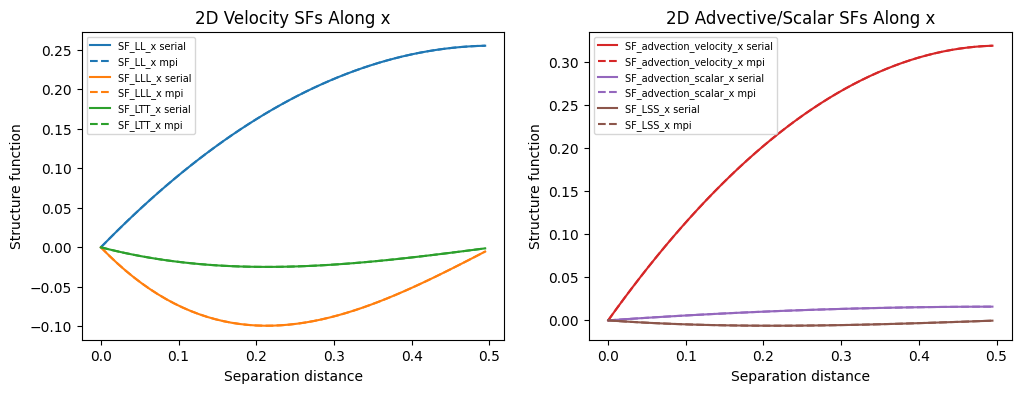

In [3]:
data = np.load(OUT / "ex_2d_mpi_compare.npz")
for name in ["SF_advection_velocity_x", "SF_advection_scalar_x", "SF_LL_x", "SF_TT_x", "SF_SS_x", "SF_LLL_x", "SF_LTT_x", "SF_LSS_x"]:
    diff = np.max(np.abs(data[f"serial_{name}"] - data[f"mpi_{name}"]))
    print(name, diff)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color in zip(["SF_LL_x", "SF_LLL_x", "SF_LTT_x"], ["C0", "C1", "C2"]):
    axes[0].plot(data["x_diffs"], data[f"serial_{name}"], color=color, linestyle="-", label=f"{name} serial")
    axes[0].plot(data["x_diffs"], data[f"mpi_{name}"], color=color, linestyle="--", label=f"{name} mpi")
for name, color in zip(["SF_advection_velocity_x", "SF_advection_scalar_x", "SF_LSS_x"], ["C3", "C4", "C5"]):
    axes[1].plot(data["x_diffs"], data[f"serial_{name}"], color=color, linestyle="-", label=f"{name} serial")
    axes[1].plot(data["x_diffs"], data[f"mpi_{name}"], color=color, linestyle="--", label=f"{name} mpi")
axes[0].set_title("2D Velocity SFs Along x")
axes[1].set_title("2D Advective/Scalar SFs Along x")
for ax in axes:
    ax.set_xlabel("Separation distance")
    ax.set_ylabel("Structure function")
    ax.legend(fontsize=7)
plt.show()
